In [1]:
import pandas as pd
import numpy as np
import zipfile

zip_path = "preprocessed_data1.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("preprocessed_data1.csv") as f:
        prep_df = pd.read_csv(f)

print(prep_df.shape)

(39119, 12)


In [2]:
prep_df1 = prep_df[prep_df['preamble'].notna() & prep_df['description'].notna() & prep_df['sentence'].notna()]
prep_df1.shape

(39119, 12)

In [3]:
df_with_marking = pd.read_csv("df_with_marking_final.csv")
df_with_marking

,id,region,entryDate,names,judge,decision,accused,articles,link_text,gender_accused,...,preamble,description,sentence,victim_count,killer_count,extracted_prison_term,prison_term_re,num_victims,has_woman_victim,has_man_victim
0,57844,29,2018-05-11,Газизов Дмитрий Рустамович - ст.105 ч.1 УК РФ,Аршинов Алексей Александрович,Вынесен ПРИГОВОР,Газизов Дмитрий Рустамович,ст.105 ч.1,http://lomonosovsky--arh.sudrf.ru/modules.php?...,мужчина,...,Дело <№> (29RS0<№>-58)\nПРИГОВОР\nименем Росси...,УСТАНОВИЛ:\nГ.Д.Р. совершил убийство при следу...,ПРИГОВОРИЛ:\nГ.Д.Р. признать виновным в соверш...,1,1,NaN,6.0,1,0,1
1,71745,23,2019-08-26,"Жмурко Юрий Геннадьевич - ст.167 ч.1, ст.105 ч...",Сапега Н.Н.,Вынесен ПРИГОВОР,Жмурко Юрий Геннадьевич,"ст.167 ч.1, ст.105 ч.1",http://novopokrovsky--krd.sudrf.ru/modules.php...,мужчина,...,К делу № 1-141/2019 г.\nПРИГОВОР\nИменем Росси...,"УСТАНОВИЛ:\nЖмурко Ю.Г. совершил убийство, т.е...",ПРИГОВОРИЛ:\nПризнать Жмурко Юрия Геннадьевича...,1,1,NaN,8.0,1,0,1
2,41579,50,2017-06-30,"Скворцов Евгений Владимирович - ст.325 ч.1, ст...",Мядзелец О.А.,Вынесен ПРИГОВОР,"Скворцов Евгений Владимирович, Скородумов Серг...","ст.325 ч.1, ст.325 ч.1, ст.325 ч.2, ст.162 ч.4...",http://oblsud--mo.sudrf.ru/modules.php?name=su...,"['мужчина', 'мужчина']",...,ПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ\n25 дека...,УСТАНОВИЛ:\nВердиктом коллегии присяжных засед...,ПРИГОВОРИЛ:\nСкородумова Сергея Юрьевича призн...,2,2,NaN,2017.0,2,1,0
3,116462,50,2022-05-04,"Матвеев Сергей Владимирович - ст. 30 ч.3, ст.1...",Перминова Е.А.,Вынесен ПРИГОВОР,Матвеев Сергей Владимирович,"ст. 30 ч.3, ст.105 ч.1",http://volokolamsk--mo.sudrf.ru/modules.php?na...,мужчина,...,Решение по уголовному делу\nИнформация по делу...,УСТАНОВИЛ:\nМатвеев С.В. совершил умышленное п...,ПРИГОВОРИЛ:\nпризнать виновным в совершении пр...,1,1,NaN,3.0,1,0,1
4,102232,38,2021-04-19,Шамов Сергей Викторович - ст.105 ч.1 УК РФ,Иванов Д.В.,Вынесен ПРИГОВОР,Шамов Сергей Викторович,ст.105 ч.1,http://angarsky--irk.sudrf.ru/modules.php?name...,мужчина,...,ПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ\nг.Ангар...,У С Т А Н О В И Л:\nНа основании вердикта колл...,ПРИГОВОРИЛ:\nПризнать Ш.С.В. виновным в соверш...,1,1,9.25,9.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,122495,78,2022-03-01,"ТАРАКАНОВ ВЛАДИМИР ВЛАДИМИРОВИЧ - ст. 30 ч.3, ...",Гулевич Станислав Анатольевич,Вынесен ПРИГОВОР,Тараканов Владимир Владимирович,"ст. 30 ч.3, ст.105 ч.1",http://nvs--spb.sudrf.ru/modules.php?name=sud_...,мужчина,...,Дело № 1-589/22 (78 BS 0015-01-2022-00231414)\...,У С Т А Н О В И Л :\nПодсудимый Тараканов В.В....,П Р И Г О В О Р И Л :\nПризнать Тараканова Вла...,1,1,NaN,4.0,1,0,1
96,79171,60,2018-12-04,Немтинов Сергей Викторович - ст.105 ч.1 УК РФ,Сергеева Надежда Николаевна,Вынесен ПРИГОВОР,Немтинов Сергей Викторович,ст.105 ч.1,http://pskovsky--psk.sudrf.ru/modules.php?name...,мужчина,...,Дело ***\nПРИГОВОР\nИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИ...,"УСТАНОВИЛ:\nНемтинов С.В. совершил убийство, т...",ПРИГОВОРИЛ:\nПризнать Немтинова Сергея Викторо...,1,1,NaN,2019.0,1,1,0
97,31607,24,2017-07-31,Баженов Дмитрий Викторович - ст.105 ч.1 УК РФ,Безрукова Ольга Васильевна,Вынесен ПРИГОВОР,Баженов Дмитрий Викторович,ст.105 ч.1,http://igarka--krk.sudrf.ru/modules.php?name=s...,мужчина,...,Дело №\nП Р И Г О В О Р\nИменем Российской Фед...,У С Т А Н О В И Л:\nБаженов Д.В. совершил убий...,П Р И Г О В О Р И Л:\nБаженова Д.В. признать в...,1,1,NaN,2017.0,1,1,0
98,14640,50,2016-01-11,Меликян Тарон Акопи - ст.105 ч.1 УК РФ,Попова Марина Николаевна,Вынесен ПРИГОВОР,Меликян Тарон Акопи,ст.105 ч.1,http://luberetzy--mo.sudrf.ru/modules.php?name...,мужчина,...,Дело №\nПРИГОВОР\nименем Российской Федерации\...,"УСТАНОВИЛ:\nМеликян Т.А. совершил убийство, то...",ПРИГОВОРИЛ:\nМеликяна Т. А. признать виновным ...,1,1,NaN,8.0,1,1,0


In [4]:
import re

def count_killers(names_text: str) -> int:
    text = names_text.replace('\n', ' ').replace('\r', ' ').strip()

    people = re.split(r'\s*,\s*(?=[^,]*?\s*-\s*ст\.)', text)

    count = 0
    for person in people:
        # print(person)
        if '105' in person:
            count += 1
    # print("end")
    return count

In [5]:
df_with_marking['killer_count'] = df_with_marking['names'].apply(count_killers)

In [6]:
df_with_marking.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'gender_accused', 'alcohol', 'drugs',
       'mental_disorder', 'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'preamble', 'description', 'sentence', 'victim_count',
       'killer_count', 'extracted_prison_term', 'prison_term_re',
       'num_victims', 'has_woman_victim', 'has_man_victim'],
      dtype='object')

In [7]:
# import pandas as pd
# import numpy as np
# import zipfile

# zip_path = "sampled_data.zip"

# with zipfile.ZipFile(zip_path, "r") as z:
#     with z.open("sampled_data.csv") as f:
#         df_3000 = pd.read_csv(f)

# print(df_3000.shape)
df_3000 = pd.read_csv('3k_3.csv')

In [8]:
df_3000.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'killer_count', 'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim', 'clean_description3', 'predictions3',
       'predicted_time_of_day', 'predicted_location', 'predicted_method',
       'predicted_relationship3'],
      dtype='object')

In [9]:
df_no_marking = prep_df[(~prep_df['id'].isin(df_with_marking['id'])) & (~prep_df['id'].isin(df_3000['id']))]
df_no_marking.shape

(36019, 12)

# Предобработка

In [10]:
df_3000 = df_3000[~df_3000['id'].isin(df_with_marking['id'])]
df_3000.shape

(3000, 31)

In [11]:
full_df = df_no_marking.sample(n=7000, random_state=42)
full_df = pd.concat([full_df, df_with_marking, df_3000])
full_df.shape

(10100, 57)

In [12]:
# df_with_marking1 = full_df[full_df['id'].isin(df_with_marking['id'])]
# df_with_marking1.shape

In [13]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

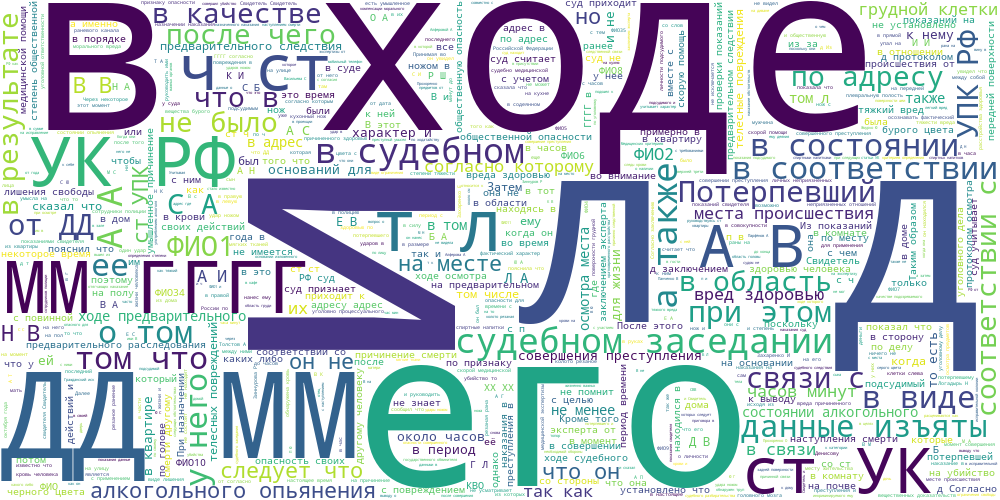

In [14]:
draw_wordcloud(df_with_marking.description)

In [13]:
import re
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm import tqdm
from functools import lru_cache

nltk.download("stopwords")
custom_stopwords = set([
    "в", "мм", "гггг", "дд", "ук", "рф", "ст", "д", "и", "ч", "ходе", "т", "л"
])

all_stopwords = set(stopwords.words("russian")).union(custom_stopwords)
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=100000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    words = text.split()
    
    lemmas = [lemmatize_word(word) for word in words if word not in all_stopwords]
    return " ".join(lemmas)

tqdm.pandas()
full_df["tfidf_description_prep"] = full_df["description"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_preamble_prep"] = full_df["preamble"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_sentence_prep"] = full_df["sentence"].astype(str).progress_apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zephyrus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 10100/10100 [00:05<00:00, 1939.32it/s]


In [14]:
import re
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm import tqdm

nltk.download("stopwords")
custom_stopwords = set([
    "в", "мм", "гггг", "дд", "ук", "рф", "ст", "д", "и", "ч", "ходе", "т", "л"
])

all_stopwords = set(stopwords.words("russian")).union(custom_stopwords)
morph = pymorphy3.MorphAnalyzer()

def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    return text

tqdm.pandas()
full_df["tfidf_description_prep_no_lemma"] = full_df["description"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_preamble_prep_no_lemma"] = full_df["preamble"].astype(str).progress_apply(preprocess_text)
full_df["tfidf_sentence_prep_no_lemma"] = full_df["sentence"].astype(str).progress_apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zephyrus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 10100/10100 [00:01<00:00, 6398.32it/s]


In [15]:
def preprocess_text_w2v(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()

    words = text.split()
    return [word for word in words if word not in all_stopwords and len(word) > 1]

tqdm.pandas()
full_df["w2v_description_prep"] = full_df["description"].astype(str).progress_apply(preprocess_text_w2v)
full_df["w2v_preamble_prep"] = full_df["preamble"].astype(str).progress_apply(preprocess_text_w2v)
full_df["w2v_sentence_prep"] = full_df["sentence"].astype(str).progress_apply(preprocess_text_w2v)

100%|██████████| 10100/10100 [00:03<00:00, 3165.91it/s]


In [16]:
extracted_features = ["gender_accused", "alcohol", "drugs", "prior_convictions",
    "relationship_between_accused_and_victim",
    "time_of_day", "location",
    "method", "motive",
    "precrime_argument", "prison_term", "has_woman_victim", "has_man_victim"]
len(extracted_features)

13

In [17]:
description_features = ["gender_accused", "alcohol", "drugs",
                        "relationship_between_accused_and_victim", 
                        "time_of_day", "location", "method", "motive", "precrime_argument", "has_woman_victim", "has_man_victim"]
sentence_features = ["prison_term"]

preamble_desctiption_features = ["prior_convictions"]

len(description_features), len(sentence_features), len(preamble_desctiption_features)

(11, 1, 1)

In [18]:
features_accused = ["gender_accused", "alcohol", "drugs", 
                    "prior_convictions", "relationship_between_accused_and_victim", "prison_term"]

features_victim = ["has_woman_victim", "has_man_victim"]

features_common = ["time_of_day",
                    "location", "method", "motive", "precrime_argument"]

len(features_accused), len(features_victim), len(features_common)

(6, 2, 5)

In [19]:
df_with_marking1 = full_df[full_df['id'].isin(df_with_marking['id'])]
df_with_marking1.shape

(100, 66)

In [20]:
df_gold_ = df_with_marking1[df_with_marking1["killer_count"] == 1]
df_gold_.shape

(97, 66)

In [21]:
full_df['killer_count'] = full_df['names'].apply(count_killers)
full_df1 = full_df[full_df["killer_count"] == 1]
full_df1.shape

(9846, 66)

In [22]:
df_weak = full_df1[full_df1['id'].isin(df_3000['id'])]
df_weak.shape

(3000, 66)

In [23]:
df_weak1 = df_weak[df_weak["killer_count"] == 1]
df_weak1.shape

(3000, 66)

In [24]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak, test_size=0.2, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((2400, 66), (300, 66), (300, 66))

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

def average_word_vectors(tokens_list, model, vector_size):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def getX_trainVal(col, df_train, df_val, df_test, full_df_for_vectorizer, vectorizer_name="tfidf", lemmatized=False, trial=None):
    full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_val['id'])) & (~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]
    
    if vectorizer_name == "tfidf":
        max_df = trial.suggest_float('max_df', 0.5, 1.0)
        min_df = trial.suggest_int('min_df', 1, 20)
        max_features = trial.suggest_int('max_features', 500, 2000)

        if lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep"] + full_df_for_vectorizer["tfidf_description_prep"] + full_df_for_vectorizer["tfidf_sentence_prep"])

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_sentence_prep"])
                X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep"] + df_val["tfidf_sentence_prep"])
                return X_train_, X_val_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_description_prep"])
            #     return X_train_, X_val_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_description_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep"] + df_val["tfidf_description_prep"])
            #     return X_train_, X_val_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_sentence_prep"])
            #     return X_train_, X_val_
            
       
        elif not lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep_no_lemma"] + full_df_for_vectorizer["tfidf_description_prep_no_lemma"] + full_df_for_vectorizer["tfidf_sentence_prep_no_lemma"])

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_sentence_prep_no_lemma"])
                X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep_no_lemma"] + df_val["tfidf_sentence_prep_no_lemma"])
                return X_train_, X_val_
            
            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_val_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_description_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_preamble_prep_no_lemma"] + df_val["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_val_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep_no_lemma"])
            #     X_val_ = vectorizer.transform(df_val["tfidf_sentence_prep_no_lemma"])
            #     return X_train_, X_val_

    if vectorizer_name == "word2vec":
        vector_size = trial.suggest_int("w2v_vector_size", 100, 300)
        window = trial.suggest_int("w2v_window", 2, 8)
        min_count = trial.suggest_int("w2v_min_count", 1, 3)
        
        sentences = list(full_df_for_vectorizer["w2v_preamble_prep"]) + \
                    list(full_df_for_vectorizer["w2v_description_prep"]) + \
                    list(full_df_for_vectorizer["w2v_sentence_prep"])

        w2v_model = Word2Vec(sentences=sentences, vector_size=vector_size,
                         window=window, min_count=min_count, workers=4, seed=42)

        vector_size = w2v_model.vector_size

        if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
            X_train_ = np.vstack(
                (df_train["w2v_preamble_prep"] + df_train["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            X_val_ = np.vstack(
                (df_val["w2v_preamble_prep"] + df_val["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            return X_train_, X_val_

        # if col in description_features:
        #     X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_val_ = np.vstack(df_val["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_val_
        
        # elif col in preamble_desctiption_features:
        #     X_train_ = np.vstack(
        #         (df_train["w2v_preamble_prep"] + df_train["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     X_val_ = np.vstack(
        #         (df_val["w2v_preamble_prep"] + df_val["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     return X_train_, X_val_
        
        # elif col in sentence_features:
        #     X_train_ = np.vstack(df_train["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_val_ = np.vstack(df_val["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_val_

In [135]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import os
import joblib

def average_word_vectors(tokens_list, model, vector_size):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def getX_trainTest(col, df_train, df_val, df_test, full_df_for_vectorizer, vectorizer_name="tfidf", lemmatized=False, best_params=None, save=False, save_path="saved_models"):
    if df_val is not None:
        full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_val['id'])) & (~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]
    else:
        full_df_for_vectorizer = full_df_for_vectorizer[(~full_df_for_vectorizer['id'].isin(df_test['id'])) & (~full_df_for_vectorizer['id'].isin(df_gold_['id']))]

    if vectorizer_name == "tfidf":
        max_df = best_params['max_df']
        min_df = best_params['min_df']
        max_features = best_params['max_features']

        if lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep"] + full_df_for_vectorizer["tfidf_description_prep"] + full_df_for_vectorizer["tfidf_sentence_prep"])
            if save:
                tfidf_filename = f"{save_path}/vectorizer_{col}_{'lemma' if lemmatized else 'nolem'}.joblib"
                joblib.dump(vectorizer, tfidf_filename)

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term', 'log_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_sentence_prep"])
                X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep"] + df_test["tfidf_sentence_prep"])
                return X_train_, X_test_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_description_prep"])
            #     return X_train_, X_test_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep"] + df_train["tfidf_description_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep"] + df_test["tfidf_description_prep"])
            #     return X_train_, X_test_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_sentence_prep"])
            #     return X_train_, X_test_

        elif not lemmatized:
            vectorizer = TfidfVectorizer(max_df=max_df,
                                        min_df=min_df,
                                        max_features=max_features)
            vectorizer.fit(full_df_for_vectorizer["tfidf_preamble_prep_no_lemma"] + full_df_for_vectorizer["tfidf_description_prep_no_lemma"] + full_df_for_vectorizer["tfidf_sentence_prep_no_lemma"])
            if save:
                tfidf_filename = f"{save_path}/vectorizer_{col}_{'lemma' if lemmatized else 'nolem'}.joblib"
                joblib.dump(vectorizer, tfidf_filename)

            if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term', 'log_prison_term']:
                X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_sentence_prep_no_lemma"])
                X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep_no_lemma"] + df_test["tfidf_sentence_prep_no_lemma"])
                return X_train_, X_test_

            # if col in description_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_description_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_test_
            
            # elif col in preamble_desctiption_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_preamble_prep_no_lemma"] + df_train["tfidf_description_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_preamble_prep_no_lemma"] + df_test["tfidf_description_prep_no_lemma"])
            #     return X_train_, X_test_
            
            # elif col in sentence_features:
            #     X_train_ = vectorizer.transform(df_train["tfidf_sentence_prep_no_lemma"])
            #     X_test_ = vectorizer.transform(df_test["tfidf_sentence_prep_no_lemma"])
            #     return X_train_, X_test_

    if vectorizer_name == "word2vec":
        vector_size = best_params['w2v_vector_size']
        window = best_params['w2v_window']
        min_count = best_params['w2v_min_count']
        
        sentences = list(full_df_for_vectorizer["w2v_preamble_prep"]) + \
                    list(full_df_for_vectorizer["w2v_description_prep"]) + \
                    list(full_df_for_vectorizer["w2v_sentence_prep"])

        w2v_model = Word2Vec(sentences=sentences, vector_size=vector_size,
                         window=window, min_count=min_count, workers=4, seed=42)
        if save:
            w2v_filename = f"{save_path}/word2vec_model_{col}.model"
            w2v_model.save(w2v_filename)

        vector_size = w2v_model.vector_size

        if col in ['predicted_gender', 'predicted_prior_convictions', 'predicted_prison_term']:
            X_train_ = np.vstack(
                (df_train["w2v_preamble_prep"] + df_train["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            X_test_ = np.vstack(
                (df_test["w2v_preamble_prep"] + df_test["w2v_sentence_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
            )
            return X_train_, X_test_

        # if col in description_features:
        #     X_train_ = np.vstack(df_train["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_test_ = np.vstack(df_test["w2v_description_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_test_
        
        # elif col in preamble_desctiption_features:
        #     X_train_ = np.vstack(
        #         (df_train["w2v_preamble_prep"] + df_train["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     X_test_ = np.vstack(
        #         (df_test["w2v_preamble_prep"] + df_test["w2v_description_prep"]).apply(lambda x: average_word_vectors(x, w2v_model, vector_size))
        #     )
        #     return X_train_, X_test_
        
        # elif col in sentence_features:
        #     X_train_ = np.vstack(df_train["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     X_test_ = np.vstack(df_test["w2v_sentence_prep"].apply(lambda x: average_word_vectors(x, w2v_model, vector_size)))
        #     return X_train_, X_test_

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import issparse
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

def train_and_validate(
    col,
    lemmatized=False,
    vectorizer_name="tfidf",
    model_name="catboost",
    trial=None,
):
    X_train_col, X_val_col = getX_trainVal(col=col, df_train=df_train_, df_val=df_val_, df_test=df_test_, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, trial=trial)   

    y_train = df_train_[col]
    y_val = df_val_[col]

    # print(1)

    def get_model():
        if model_name == "catboost":
            return CatBoostRegressor(
                iterations=trial.suggest_int("iterations", 500, 1000),
                depth=trial.suggest_int("depth", 3, 7),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                loss_function="MAE",
                verbose=False,
            )
        elif model_name == "random_forest":
            return RandomForestRegressor(
                n_estimators=trial.suggest_int("n_estimators", 100, 300),
                max_depth=trial.suggest_int("max_depth", 5, 50),
                min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
                random_state=42,
                n_jobs=-1,
            )

    # print(2)
    model = get_model()
    if model_name == "catboost":
        model.fit(X_train_col, y_train)
    else:
        X_train_input = X_train_col.toarray() if issparse(X_train_col) else X_train_col
        model.fit(X_train_input, y_train)
    
    # print(3)

    X_val_input = X_val_col.toarray() if issparse(X_val_col) else X_val_col
    y_pred = model.predict(X_val_input)

    mae = mean_absolute_error(y_val, y_pred)
    return mae

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import issparse
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

def train_and_test(
    col,
    best_params,
    lemmatized=False,
    vectorizer_name="tfidf",
    model_name="catboost",
    df_train1=None,
    df_val1=None,
    df_test1=None,
    save=False,
    save_path="saved_models"
):
    if save:
        X_train_col, X_test_col = getX_trainTest(col=col, df_train=df_train1, df_val=df_val1, df_test=df_test1, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, best_params=best_params, save=True, save_path="saved_models")     
    else:
        X_train_col, X_test_col = getX_trainTest(col=col, df_train=df_train1, df_val=df_val1, df_test=df_test1, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, best_params=best_params) 
    # print(col)
    metrics_list = []

    y_train = df_train1[col]
    y_test = df_test1[col]

    # print(1)

    # print(4)
    def get_model():
        if model_name == "catboost":
            return CatBoostRegressor(
                iterations=best_params["iterations"],
                depth=best_params["depth"],
                learning_rate=best_params["learning_rate"],
                loss_function="MAE",
                verbose=False,
            )
        elif model_name == "random_forest":
            return RandomForestRegressor(
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                min_samples_split=best_params["min_samples_split"],
                min_samples_leaf=best_params["min_samples_leaf"],
                random_state=42,
                n_jobs=-1,
            )

    model = get_model()

    # print(2)
    if model_name == "catboost":
        model.fit(X_train_col, y_train)
    else:
        X_train_input = X_train_col.toarray() if issparse(X_train_col) else X_train_col
        model.fit(X_train_input, y_train)
    
    # print(3)
    if save:
        os.makedirs(save_path, exist_ok=True)
        model_filename = f"{save_path}/model_{col}_{model_name}_{vectorizer_name}_{'lemma' if lemmatized else 'nolem'}_.joblib"
        joblib.dump(model, model_filename)

    X_test_input = X_test_col.toarray() if issparse(X_test_col) else X_test_col
    y_pred = model.predict(X_test_input)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    metrics_list.append({
        "Feature": col,
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    })

    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df

In [74]:
from itertools import product
import optuna

def optimize_hyperparams(col, vect, model, lemm, n_trials=20):
    def objective(trial):
        return train_and_validate(
            col=col,
            lemmatized=lemm,
            vectorizer_name=vect,
            model_name=model,
            trial=trial,
        )
            
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    best_f1 = study.best_value
    best_params = study.best_params
    return best_f1, best_params

In [ ]:
def full_grid_search_with_optuna(col, n_trials=20):
    vectorizer_options = ["tfidf", "word2vec"]
    model_options = ["catboost", "random_forest"]
    lemmatized_options = [False, True]

    best_result = {
        "Feature": col,
        "Best mae": -1,
        "Best Combo": None,
        "Best Params": None
    }

    results = []

    for vect, model, lemm in product(
        vectorizer_options, model_options,
        lemmatized_options
    ):
        if vect == "word2vec" and lemm:
            continue

        print(f"\nТестируем: {vect}, {model}, lemm={lemm}")

        mae_val, best_params = optimize_hyperparams(
            col, vect, model, lemm, n_trials=n_trials
        )
        print(f"mae (val) = {mae_val:.4f}, Best Params = {best_params}")

        metrics_df = train_and_test(
                    col,
                    best_params,
                    lemmatized=lemm,
                    vectorizer_name=vect,
                    model_name=model,
                    df_train1=df_train_,
                    df_val1=df_val_,
                    df_test1=df_test_,
                )
        # metrics_list.append({
        #     "Feature": col,
        #     "MAE": mae,
        #     "MSE": mse,
        #     "R2": r2
        # })


        r2_test = metrics_df['R2'].values[0]
        mse_test = metrics_df['MSE'].values[0]
        mae_test = metrics_df['MAE'].values[0]
        print(f"r2_test = {r2_test:.4f}, mse_test = {mse_test:.4f}, mae_test = {mae_test:.4f}")
                
        results.append({
            'Feature': col,
            'vectorizer': vect,
            'model': model,
            "lemmatized": lemm,
            'r2': r2_test,
            'mse': mse_test,
            'mae': mae_test,
            'params': best_params
        })

        if r2_test > best_result["Best mae"]:
            best_result["Best mae"] = mae_test
            best_result["Best Combo"] = {
                "vectorizer": vect,
                "model": model,
                "lemmatized": lemm,
            }
            best_result["Best Params"] = best_params

    results_df = pd.DataFrame(results)
    return best_result, results_df

## Prison term

In [91]:
df_weak.columns

Index(['id', 'region', 'entryDate', 'names', 'judge', 'decision', 'accused',
       'articles', 'link_text', 'preamble', 'description', 'sentence',
       'gender_accused', 'alcohol', 'drugs', 'mental_disorder',
       'prior_convictions', 'gender_victim',
       'relationship_between_accused_and_victim', 'time_of_day', 'day_of_week',
       'season', 'year', 'crime_region', 'location', 'method', 'cruelty',
       'intentional', 'motive', 'witnesses', 'precrime_argument',
       'prison_term', 'victim_count', 'killer_count', 'extracted_prison_term',
       'prison_term_re', 'num_victims', 'has_woman_victim', 'has_man_victim',
       'combined_text', 'predictions', 'predicted_gender',
       'predicted_prior_convictions', 'predicted_prison_term', 'predictions2',
       'predicted_alcohol', 'predicted_precrime_argument', 'predicted_motive',
       'predicted_relationship', 'predicted_has_woman_victim',
       'predicted_has_man_victim', 'clean_description3', 'predictions3',
       'predi

In [92]:
df_weak['predicted_prison_term'].value_counts()

predicted_prison_term
9.00     345
8.00     342
7.00     267
6.00     196
10.00    182
        ... 
18.67      1
10.58      1
12.42      1
12.25      1
21.00      1
Name: count, Length: 181, dtype: int64

In [93]:
for value, count in df_weak['predicted_prison_term'].value_counts().items():
    print(f"{value}: {count}")

9.00: 345
8.00: 342
7.00: 267
6.00: 196
10.00: 182
9.50: 120
8.50: 104
11.00: 102
7.50: 90
6.50: 88
12.00: 87
5.00: 60
13.00: 55
4.00: 52
3.00: 39
15.00: 38
14.00: 33
17.00: 32
10.50: 29
16.00: 25
9.83: 22
18.00: 21
11.50: 19
4.50: 19
5.50: 18
3.50: 17
19.00: 15
2.00: 12
12.50: 12
9.08: 12
6.08: 12
1.50: 11
13.50: 11
6.17: 10
2.50: 10
20.00: 10
6.75: 9
1.00: 9
7.25: 8
8.83: 8
9.25: 8
14.50: 7
6.25: 6
7.83: 5
9.17: 5
1.83: 5
9.75: 5
7.67: 5
9.92: 5
7.08: 5
8.75: 4
6.83: 4
4.83: 4
10.08: 4
9.58: 4
7.17: 4
10.17: 4
8.08: 4
24.00: 4
16.50: 3
3.67: 3
6.33: 3
10.25: 3
8.42: 3
22.00: 3
23.00: 3
6.58: 3
9.42: 3
11.25: 3
10.92: 3
5.08: 3
2.17: 3
8.67: 3
8.17: 3
1.08: 3
1.25: 3
9.03: 3
15.50: 3
10.33: 3
9.67: 3
9.33: 2
18.08: 2
11.83: 2
0.50: 2
12.08: 2
18.50: 2
3.83: 2
12.67: 2
8.92: 2
7.58: 2
5.25: 2
7.75: 2
7.42: 2
17.08: 2
6.42: 2
8.33: 2
2.67: 2
6.67: 2
11.08: 2
10.03: 2
11.33: 2
14.75: 2
12.17: 2
7.92: 1
2.92: 1
19.00, 13.67: 1
9999.00: 1
1.67: 1
12.92: 1
11.25, 2.75: 1
25.00: 1
23.50: 1
1

In [94]:
sum(df_weak['predicted_prison_term'].isna())

170

In [95]:
df_weak_1_killer = df_weak.copy()
df_weak_1_killer = df_weak_1_killer[df_weak_1_killer['predicted_prison_term'].notna()]
sum(df_weak_1_killer['predicted_prison_term'].isna())

0

In [96]:
df_weak_1_killer = df_weak_1_killer[~df_weak_1_killer['predicted_prison_term'].isin(['19.00, 13.67', '11.25, 2.75', '4.00, 9.50', '15.00, 4.50', '7.00, 9.50, 19.00', '13.00, 13.00', '22.00, 12.00', '13.83, 14.00', '17.00, 15.00, 10.00', '11.00, 7.00', '9999'])]

In [97]:
for value, count in df_weak_1_killer['predicted_prison_term'].value_counts().items():
    print(f"{value}: {count}")

9.00: 345
8.00: 342
7.00: 267
6.00: 196
10.00: 182
9.50: 120
8.50: 104
11.00: 102
7.50: 90
6.50: 88
12.00: 87
5.00: 60
13.00: 55
4.00: 52
3.00: 39
15.00: 38
14.00: 33
17.00: 32
10.50: 29
16.00: 25
9.83: 22
18.00: 21
4.50: 19
11.50: 19
5.50: 18
3.50: 17
19.00: 15
6.08: 12
2.00: 12
12.50: 12
9.08: 12
13.50: 11
1.50: 11
20.00: 10
6.17: 10
2.50: 10
1.00: 9
6.75: 9
8.83: 8
7.25: 8
9.25: 8
14.50: 7
6.25: 6
1.83: 5
9.75: 5
7.08: 5
9.17: 5
7.83: 5
7.67: 5
9.92: 5
9.58: 4
10.17: 4
8.08: 4
6.83: 4
8.75: 4
7.17: 4
10.08: 4
4.83: 4
24.00: 4
9.03: 3
5.08: 3
6.58: 3
10.33: 3
3.67: 3
16.50: 3
6.33: 3
10.25: 3
1.25: 3
15.50: 3
22.00: 3
1.08: 3
2.17: 3
10.92: 3
9.42: 3
11.25: 3
9.67: 3
8.17: 3
8.42: 3
8.67: 3
23.00: 3
7.75: 2
18.08: 2
8.92: 2
12.08: 2
7.42: 2
7.58: 2
0.50: 2
9.33: 2
11.83: 2
18.50: 2
3.83: 2
12.67: 2
14.75: 2
5.25: 2
6.67: 2
11.08: 2
12.17: 2
11.33: 2
10.03: 2
8.33: 2
6.42: 2
17.08: 2
2.67: 2
1.67: 1
9999.00: 1
13.17: 1
12.75: 1
2.92: 1
7.92: 1
7.03: 1
9.54: 1
7.01: 1
6.62: 1
23.50: 1


In [98]:
df_weak_1_killer['predicted_prison_term'] = pd.to_numeric(df_weak_1_killer['predicted_prison_term'], errors='coerce')

In [84]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((1974, 66), (423, 66), (423, 66))

In [85]:
df_gold_['prison_term'].value_counts()

prison_term
9.00     13
8.00     12
7.00     10
9.50      7
7.50      6
6.50      5
6.00      4
8.50      3
11.00     3
12.00     2
20.00     2
4.00      2
3.00      2
5.00      2
11.50     1
6.60      1
8.75      1
1.67      1
8.67      1
9.91      1
4.83      1
18.50     1
2.50      1
10.00     1
8.08      1
13.83     1
9.83      1
18.00     1
6.92      1
1.00      1
13.00     1
9.25      1
5.50      1
Name: count, dtype: int64

In [86]:
df_gold_.loc[:, 'predicted_prison_term'] = pd.to_numeric(df_gold_['prison_term'], errors='coerce')
df_gold_['predicted_prison_term'].value_counts()

predicted_prison_term
9.0      13
8.0      12
7.0      10
9.5       7
7.5       6
6.5       5
6.0       4
8.5       3
11.0      3
12.0      2
20.0      2
4.0       2
3.0       2
5.0       2
11.5      1
6.6       1
8.75      1
1.67      1
8.67      1
9.91      1
4.83      1
18.5      1
2.5       1
10.0      1
8.08      1
13.83     1
9.83      1
18.0      1
6.92      1
1.0       1
13.0      1
9.25      1
5.5       1
Name: count, dtype: int64

In [ ]:
sum(df_gold_['predicted_prison_term'].isna())

5

In [120]:
df_gold_ = df_gold_[df_gold_['predicted_prison_term'].notna()]

In [87]:
best, results = full_grid_search_with_optuna("predicted_prison_term", n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best)
results

[I 2025-04-25 13:48:45,132] A new study created in memory with name: no-name-25b86d38-2075-4864-a914-526e8d995bbd



Тестируем: tfidf, catboost, lemm=False


[I 2025-04-25 13:49:15,657] Trial 0 finished with value: 1.687842216880283 and parameters: {'max_df': 0.706152907332636, 'min_df': 13, 'max_features': 1845, 'iterations': 537, 'depth': 3, 'learning_rate': 0.19131493198560437}. Best is trial 0 with value: 1.687842216880283.
[I 2025-04-25 13:49:53,238] Trial 1 finished with value: 1.7228516639765585 and parameters: {'max_df': 0.5761363747004908, 'min_df': 1, 'max_features': 1967, 'iterations': 789, 'depth': 5, 'learning_rate': 0.15064012222563253}. Best is trial 0 with value: 1.687842216880283.
[I 2025-04-25 13:50:32,928] Trial 2 finished with value: 1.68512132995245 and parameters: {'max_df': 0.8050745959316781, 'min_df': 10, 'max_features': 1583, 'iterations': 991, 'depth': 5, 'learning_rate': 0.023670999975209075}. Best is trial 2 with value: 1.68512132995245.
[I 2025-04-25 13:51:11,274] Trial 3 finished with value: 1.724171418371859 and parameters: {'max_df': 0.6057294687853404, 'min_df': 15, 'max_features': 1059, 'iterations': 760, 

r2 (val) = 1.6851, Best Params = {'max_df': 0.8050745959316781, 'min_df': 10, 'max_features': 1583, 'iterations': 991, 'depth': 5, 'learning_rate': 0.023670999975209075}


[I 2025-04-25 13:52:32,795] A new study created in memory with name: no-name-ea37e1cb-f82c-45c0-a8ef-74b6293e1c0e


...

[I 2025-04-25 14:15:59,648] A new study created in memory with name: no-name-2ccba5ce-f40a-48a1-8da1-37f20d9fab8f


r2_test = 0.3622, mse_test = 7.9921, mae_test = 2.0042

Тестируем: word2vec, random_forest, lemm=False


[I 2025-04-25 14:18:06,741] Trial 0 finished with value: 15.372965162821117 and parameters: {'w2v_vector_size': 154, 'w2v_window': 6, 'w2v_min_count': 1, 'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 9}. Best is trial 0 with value: 15.372965162821117.
[I 2025-04-25 14:20:09,119] Trial 1 finished with value: 9.073199024060033 and parameters: {'w2v_vector_size': 152, 'w2v_window': 5, 'w2v_min_count': 1, 'n_estimators': 114, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 1 with value: 9.073199024060033.
[I 2025-04-25 14:22:16,745] Trial 2 finished with value: 9.007659087245308 and parameters: {'w2v_vector_size': 203, 'w2v_window': 2, 'w2v_min_count': 2, 'n_estimators': 186, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 7}. Best is trial 2 with value: 9.007659087245308.
[I 2025-04-25 14:24:53,263] Trial 3 finished with value: 8.271243460743614 and parameters: {'w2v_vector_size': 267, 'w2v_window': 7, 'w2v_min

r2 (val) = 5.8057, Best Params = {'w2v_vector_size': 221, 'w2v_window': 6, 'w2v_min_count': 2, 'n_estimators': 149, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 10}
r2_test = -264.8706, mse_test = 3331.5015, mae_test = 7.6697

ЛУЧШАЯ КОМБИНАЦИЯ:
{'Feature': 'predicted_prison_term', 'Best mae': 0.5236654824720468, 'Best Combo': {'vectorizer': 'tfidf', 'model': 'catboost', 'lemmatized': True}, 'Best Params': {'max_df': 0.9330546412018345, 'min_df': 20, 'max_features': 1822, 'iterations': 600, 'depth': 7, 'learning_rate': 0.025063914936057308}}


,Feature,vectorizer,model,lemmatized,r2,mse,mae,params
0,predicted_prison_term,tfidf,catboost,False,0.496455,6.309689,1.816030,"{'max_df': 0.8050745959316781, 'min_df': 10, '..."
1,predicted_prison_term,tfidf,catboost,True,0.523665,5.968727,1.578916,"{'max_df': 0.9330546412018345, 'min_df': 20, '..."
2,predicted_prison_term,tfidf,random_forest,False,-11.868629,161.250812,2.838038,"{'max_df': 0.9832163043813917, 'min_df': 2, 'm..."
3,predicted_prison_term,tfidf,random_forest,True,-1.679588,33.576674,2.127132,"{'max_df': 0.9126489675029339, 'min_df': 11, '..."
4,predicted_prison_term,word2vec,catboost,False,0.362190,7.992101,2.004153,"{'w2v_vector_size': 284, 'w2v_window': 5, 'w2v..."
5,predicted_prison_term,word2vec,random_forest,False,-264.870635,3331.501541,7.669749,"{'w2v_vector_size': 221, 'w2v_window': 6, 'w2v..."


In [103]:
metrics_for_gold = train_and_test(
    'predicted_prison_term',
    best['Best Params'],
    lemmatized=best['Best Combo']['lemmatized'],
    vectorizer_name=best['Best Combo']['vectorizer'],
    model_name=best['Best Combo']['model'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
)
metrics_for_gold

,Feature,MAE,MSE,R2
0,predicted_prison_term,1.449804,6.020327,0.410389


In [152]:
metrics_for_gold = train_and_test(
    'predicted_prison_term',
    best['Best Params'],
    lemmatized=best['Best Combo']['lemmatized'],
    vectorizer_name=best['Best Combo']['vectorizer'],
    model_name=best['Best Combo']['model'],
    df_train1=df_weak_1_killer,
    df_val1=None,
    df_test1=df_gold_,
    save=True
)
metrics_for_gold

,Feature,MAE,MSE,R2
0,predicted_prison_term,1.452186,5.945633,0.417704


In [130]:
df_weak_1_killer['log_prison_term'] = np.log(df_weak_1_killer['predicted_prison_term'])
df_gold_["predicted_prison_term"] = pd.to_numeric(df_gold_["predicted_prison_term"], errors="coerce")
df_gold_ = df_gold_[df_gold_["predicted_prison_term"].notnull() & (df_gold_["predicted_prison_term"] > 0)]
df_gold_["log_prison_term"] = np.log(df_gold_["predicted_prison_term"])

In [ ]:
df_gold_["log_prison_term"].value_counts()

In [131]:
from sklearn.model_selection import train_test_split

df_train_, df_temp = train_test_split(df_weak_1_killer, test_size=0.3, random_state=42)
df_val_, df_test_ = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train_.shape, df_val_.shape, df_test_.shape

((1974, 67), (423, 67), (423, 67))

In [136]:
best2, results2 = full_grid_search_with_optuna('log_prison_term', n_trials=5)
print("\nЛУЧШАЯ КОМБИНАЦИЯ:")
print(best2)
results2

[I 2025-04-25 15:13:02,277] A new study created in memory with name: no-name-fe82db1d-7a63-4627-b86e-e72fbbad8e1a



Тестируем: tfidf, catboost, lemm=False


[I 2025-04-25 15:14:00,830] Trial 0 finished with value: 0.21394963485904492 and parameters: {'max_df': 0.8402896948600882, 'min_df': 8, 'max_features': 1915, 'iterations': 1138, 'depth': 6, 'learning_rate': 0.014857605728061985}. Best is trial 0 with value: 0.21394963485904492.
[I 2025-04-25 15:14:43,111] Trial 1 finished with value: 0.2050453688547536 and parameters: {'max_df': 0.914247867151178, 'min_df': 8, 'max_features': 1536, 'iterations': 1109, 'depth': 5, 'learning_rate': 0.013055162991591996}. Best is trial 1 with value: 0.2050453688547536.
[I 2025-04-25 15:15:26,004] Trial 2 finished with value: 0.21602868427883895 and parameters: {'max_df': 0.7601567361336431, 'min_df': 9, 'max_features': 1784, 'iterations': 830, 'depth': 5, 'learning_rate': 0.022437036165350442}. Best is trial 1 with value: 0.2050453688547536.
[I 2025-04-25 15:16:14,383] Trial 3 finished with value: 0.2154186692941136 and parameters: {'max_df': 0.7515664836250384, 'min_df': 10, 'max_features': 1518, 'itera

mae (val) = 0.2050, Best Params = {'max_df': 0.914247867151178, 'min_df': 8, 'max_features': 1536, 'iterations': 1109, 'depth': 5, 'learning_rate': 0.013055162991591996}


[I 2025-04-25 15:17:50,528] A new study created in memory with name: no-name-92fe0e8a-f09b-4c8e-aeff-8773905fddfc


r2_test = 0.4417, mse_test = 0.0948, mae_test = 0.2136

Тестируем: tfidf, catboost, lemm=True


[W 2025-04-25 15:17:58,971] Trial 0 failed with parameters: {'max_df': 0.8004871848851927, 'min_df': 13, 'max_features': 1743} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Zephyrus\Documents\GitHub\criminal-research\myenv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Zephyrus\AppData\Local\Temp\ipykernel_23216\2976199033.py", line 6, in objective
    return train_and_validate(
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Zephyrus\AppData\Local\Temp\ipykernel_23216\874413900.py", line 13, in train_and_validate
    X_train_col, X_val_col = getX_trainVal(col=col, df_train=df_train_, df_val=df_val_, df_test=df_test_, full_df_for_vectorizer=full_df1, vectorizer_name=vectorizer_name, lemmatized=lemmatized, trial=trial)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 